# Exploring the closing auction data

This notebook looks at a few days of Nasdaq closing-auction imbalance data from Databento.

Run it from the same folder as `download_data.py`, so it can find the `data/` folder.

**What we want to understand:**
1. What one row of the raw data looks like
2. What the important columns mean
3. How one stock's imbalance changes from 3:50 to 4:00 PM
4. A first look at the strategy idea: does a big imbalance predict a bounce the next morning?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

files = sorted(Path("data/imbalance").glob("*.parquet"))
print(f"{len(files)} days downloaded, from {files[0].stem} to {files[-1].stem}")

496 days downloaded, from 2024-10-01 to 2026-09-30


## 1. One day of raw data

In [2]:
day_file = files[20]          # change the number to look at a different day
df = pd.read_parquet(day_file)

print("Day:", day_file.stem)
print("Rows:", f"{len(df):,}", "| Stocks:", df["symbol"].nunique())
df.head()

Day: 2024-10-29
Rows: 34,086 | Stocks: 100


,ts_event,rtype,publisher_id,instrument_id,ref_price,auction_time,cont_book_clr_price,auct_interest_clr_price,ssr_filling_price,ind_match_price,upper_collar,lower_collar,paired_qty,total_imbalance_qty,market_imbalance_qty,unpaired_qty,auction_type,side,auction_status,freeze_status,num_extensions,unpaired_side,significant_imbalance,symbol
ts_recv,,,,,,,,,,,,,,,,,,,,,,,,
2024-10-29 19:50:00.000628325+00:00,2024-10-29 19:50:00.000461321+00:00,20,2,12087,1180.69,1970-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,17292,11544,0,0,C,A,0,0,0,N,~,ORLY
2024-10-29 19:50:00.001272892+00:00,2024-10-29 19:50:00.001106405+00:00,20,2,2785,76.16,1970-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,68741,60157,0,0,C,B,0,0,0,N,~,CCEP
2024-10-29 19:50:00.001328400+00:00,2024-10-29 19:50:00.001162521+00:00,20,2,16276,121.39,1970-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,114125,10146,0,0,C,A,0,0,0,N,~,TTD
2024-10-29 19:50:00.001556414+00:00,2024-10-29 19:50:00.001390680+00:00,20,2,12304,141.75,1970-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,275066,27796,0,0,C,A,0,0,0,N,~,PAYX
2024-10-29 19:50:00.001834996+00:00,2024-10-29 19:50:00.001666066+00:00,20,2,279,289.84,1970-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,62344,1135,0,0,C,A,0,0,0,N,~,ADSK


In [3]:
# Which columns actually have data? (1.0 = always filled, 0.0 = always empty)
df.notna().mean().round(2).sort_values()

ts_event                   1.0
unpaired_side              1.0
num_extensions             1.0
freeze_status              1.0
auction_status             1.0
side                       1.0
auction_type               1.0
unpaired_qty               1.0
market_imbalance_qty       1.0
total_imbalance_qty        1.0
paired_qty                 1.0
lower_collar               1.0
upper_collar               1.0
ind_match_price            1.0
ssr_filling_price          1.0
auct_interest_clr_price    1.0
cont_book_clr_price        1.0
auction_time               1.0
ref_price                  1.0
instrument_id              1.0
publisher_id               1.0
rtype                      1.0
significant_imbalance      1.0
symbol                     1.0
dtype: float64

## 2. What the important columns mean

| Column | Meaning |
|---|---|
| `ts_recv` (the index) | When the message arrived, in UTC. We convert it to New York time below. |
| `symbol` | The stock ticker |
| `auction_type` | Which auction: **C = closing**, O = opening, H = halt/reopening. We only want **C**. |
| `side` | Direction of the imbalance: **B = more buyers**, **A = more sellers**, N = balanced |
| `total_imbalance_qty` | **The imbalance:** how many extra shares want to buy (or sell) than can be matched |
| `paired_qty` | Shares that are already matched, buyers and sellers who cancel out |
| `ref_price` | Nasdaq's reference price for the auction (roughly where the stock is trading) |
| `ind_match_price`, `cont_book_clr_price`, `auct_interest_clr_price` | Nasdaq's estimates of where the closing price will land. Check the table above to see which ones are filled for your data. |

Nasdaq publishes an update for every stock about once per second starting around 3:50 PM. That's why there are tens of thousands of rows per day.

In [4]:
# The values you'll see in the code columns
for col in ["auction_type", "side"]:
    print(col, df[col].value_counts().to_dict())

auction_type {'C': 33008, 'A': 1078}
side {'A': 15784, 'B': 12549, 'N': 5753}


## 3. Clean it up: closing auction only, New York time, signed imbalance

In [5]:
def clean(df):
    df = df[df["auction_type"] == "C"].copy()                       # closing auction only
    df["time_ny"] = df.index.tz_convert("America/New_York")         # UTC -> New York
    sign = df["side"].map({"B": 1, "A": -1}).fillna(0)              # buyers +, sellers -
    df["imbalance_shares"] = sign * df["total_imbalance_qty"]
    df["imbalance_dollars"] = df["imbalance_shares"] * df["ref_price"]
    cols = ["time_ny", "symbol", "side", "total_imbalance_qty", "paired_qty",
            "ref_price", "imbalance_shares", "imbalance_dollars"]
    return df[cols].reset_index(drop=True)

close_df = clean(df)
close_df.head(10)

,time_ny,symbol,side,total_imbalance_qty,paired_qty,ref_price,imbalance_shares,imbalance_dollars
0,2024-10-29 15:50:00.000628325-04:00,ORLY,A,11544,17292,1180.69,-11544.0,-13629885.36
1,2024-10-29 15:50:00.001272892-04:00,CCEP,B,60157,68741,76.16,60157.0,4581557.12
2,2024-10-29 15:50:00.001328400-04:00,TTD,A,10146,114125,121.39,-10146.0,-1231622.94
3,2024-10-29 15:50:00.001556414-04:00,PAYX,A,27796,275066,141.75,-27796.0,-3940083.00
4,2024-10-29 15:50:00.001834996-04:00,ADSK,A,1135,62344,289.84,-1135.0,-328968.40
5,2024-10-29 15:50:00.002646083-04:00,MNST,B,263926,194133,52.24,263926.0,13787494.24
6,2024-10-29 15:50:00.003178210-04:00,DASH,B,35488,80961,155.36,35488.0,5513415.68
7,2024-10-29 15:50:00.012220301-04:00,MDB,B,12923,23014,274.52,12923.0,3547621.96
8,2024-10-29 15:50:00.012659812-04:00,FAST,A,5266,172331,77.61,-5266.0,-408694.26
9,2024-10-29 15:50:00.013605106-04:00,PDD,B,49040,128429,125.24,49040.0,6141769.60


## 4. One stock's last 10 minutes

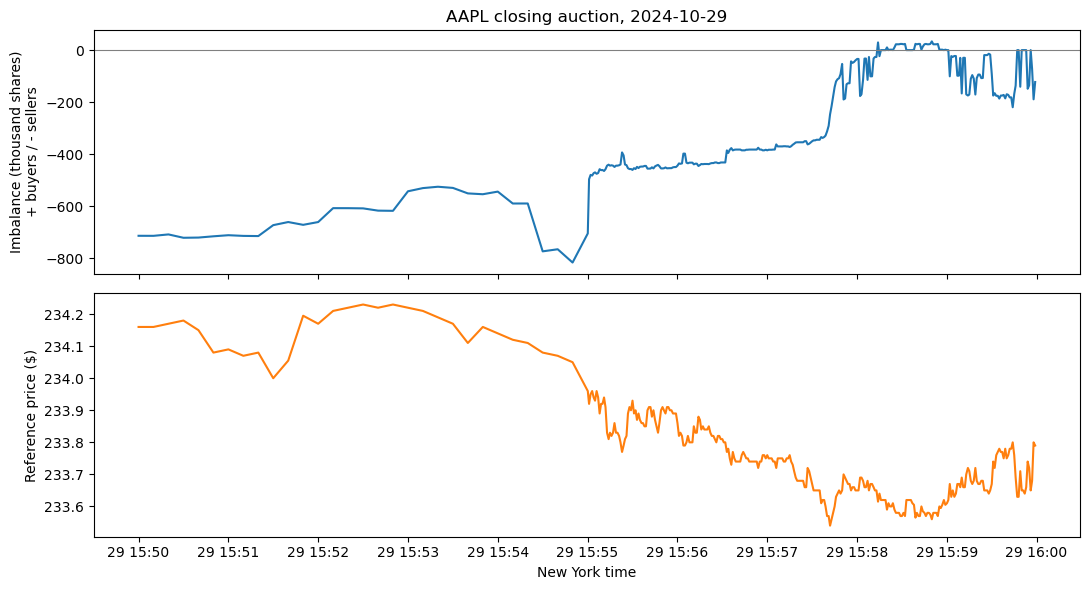

,time_ny,symbol,side,total_imbalance_qty,paired_qty,ref_price,imbalance_shares,imbalance_dollars
32535,2024-10-29 15:59:55.044669085-04:00,AAPL,A,135559,4855431,233.72,-135559.0,-31682849.48
32667,2024-10-29 15:59:56.071662782-04:00,AAPL,N,0,4978172,233.65,0.0,0.00
32710,2024-10-29 15:59:57.016016780-04:00,AAPL,A,72602,4910231,233.68,-72602.0,-16965635.36
32803,2024-10-29 15:59:58.009604371-04:00,AAPL,A,189256,4858299,233.80,-189256.0,-44248052.80
32947,2024-10-29 15:59:59.068475218-04:00,AAPL,A,122648,4890146,233.79,-122648.0,-28673875.92


In [6]:
stock = "AAPL"     # try others: NVDA, TSLA, MSFT...
s = close_df[close_df["symbol"] == stock]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(s["time_ny"], s["imbalance_shares"] / 1e3, color="tab:blue")
ax1.axhline(0, color="gray", lw=0.8)
ax1.set_ylabel("Imbalance (thousand shares)\n+ buyers / - sellers")
ax1.set_title(f"{stock} closing auction, {day_file.stem}")
ax2.plot(s["time_ny"], s["ref_price"], color="tab:orange")
ax2.set_ylabel("Reference price ($)")
ax2.set_xlabel("New York time")
plt.tight_layout()
plt.show()

# The last few updates before 4:00 PM
s.tail(5)

## 5. Several days at once: the biggest imbalances

For each stock and day, we take the **last imbalance message before 3:55 PM**. That's a moment when you could still act on it.

In [7]:
def snapshot(path, cutoff="15:55"):
    c = clean(pd.read_parquet(path))
    c = c[c["time_ny"].dt.strftime("%H:%M") < cutoff]
    last = c.sort_values("time_ny").groupby("symbol").tail(1)
    last["date"] = pd.to_datetime(path.stem)
    return last

few_days = pd.concat([snapshot(f) for f in files[20:25]], ignore_index=True)

# The 10 biggest imbalances by dollar size across these 5 days
few_days.reindex(few_days["imbalance_dollars"].abs().sort_values(ascending=False).index).head(10)

,time_ny,symbol,side,total_imbalance_qty,paired_qty,ref_price,imbalance_shares,imbalance_dollars,date
250,2024-10-31 15:54:50.061400124-04:00,MSFT,A,1615209,5517451,407.83,-1615209.0,-6.587307e+08,2024-10-31
275,2024-10-31 15:54:50.094730316-04:00,NVDA,A,3873671,22634944,133.26,-3873671.0,-5.162054e+08,2024-10-31
164,2024-10-30 15:54:50.067003276-04:00,MSFT,A,1021846,2114459,433.42,-1021846.0,-4.428885e+08,2024-10-30
105,2024-10-30 15:54:50.005529731-04:00,AAPL,A,1864325,7092610,230.10,-1864325.0,-4.289812e+08,2024-10-30
239,2024-10-31 15:54:50.050927355-04:00,AAPL,A,1844275,9950690,226.64,-1844275.0,-4.179865e+08,2024-10-31
203,2024-10-31 15:54:50.006201822-04:00,META,A,553879,1596806,567.01,-553879.0,-3.140549e+08,2024-10-31
116,2024-10-30 15:54:50.015202652-04:00,NVDA,A,1961134,11180247,139.63,-1961134.0,-2.738331e+08,2024-10-30
131,2024-10-30 15:54:50.030926261-04:00,META,A,448629,1181402,592.40,-448629.0,-2.657678e+08,2024-10-30
471,2024-11-04 15:54:50.068845478-05:00,AAPL,A,1155811,6359221,222.09,-1155811.0,-2.566941e+08,2024-11-04
442,2024-11-04 15:54:50.045922275-05:00,NVDA,A,1599578,8935894,136.53,-1599578.0,-2.183904e+08,2024-11-04


## 6. Daily prices

In [8]:
bars = pd.read_parquet("data/daily_bars.parquet")
# Daily bars are stamped at midnight UTC, so the UTC date IS the trading day (don't convert to NY time)
bars["date"] = pd.to_datetime(bars.index.date)
bars = bars[["date", "symbol", "open", "high", "low", "close", "volume"]].sort_values(["symbol", "date"])
print("Source:", pd.read_parquet("data/daily_bars.parquet")["source"].iloc[0])
bars.head()

Source: EQUS.SUMMARY


,date,symbol,open,high,low,close,volume
ts_event,,,,,,,
2024-10-01 00:00:00+00:00,2024-10-01,AAPL,229.52,229.650,223.74,226.21,63285048
2024-10-02 00:00:00+00:00,2024-10-02,AAPL,225.89,227.370,223.02,226.78,32880605
2024-10-03 00:00:00+00:00,2024-10-03,AAPL,225.14,226.805,223.32,225.67,34044158
2024-10-04 00:00:00+00:00,2024-10-04,AAPL,227.90,228.000,224.13,226.80,37345098
2024-10-07 00:00:00+00:00,2024-10-07,AAPL,224.50,225.690,221.33,221.69,39505354


## 7. First look at the strategy idea

**Question:** after a big *buy* imbalance, does the stock tend to fall from today's close to tomorrow's open? (And the reverse for sell imbalances?)

`next_open_return` = tomorrow's open / today's close − 1. If the idea works, the dots should slope **down**: big buy imbalance → negative return the next morning.

This uses only 5 days, so it's just a sanity check. The real test comes after we build the full table.

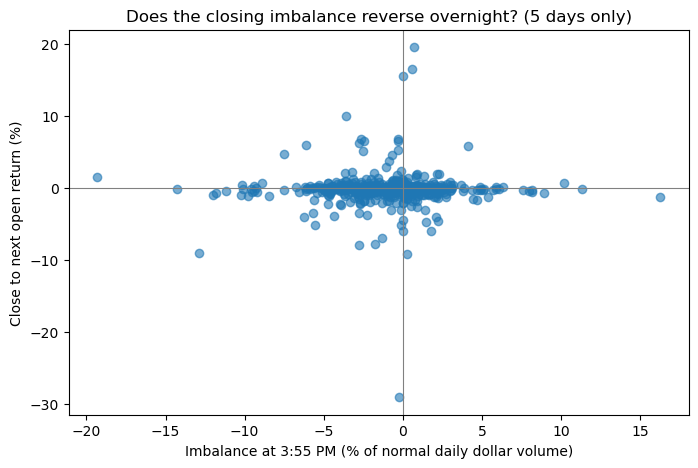

Correlation: 0.016
Negative = imbalances tend to reverse overnight, which is what we hope to see.


In [9]:
bars["next_open"] = bars.groupby("symbol")["open"].shift(-1)
bars["next_open_return"] = bars["next_open"] / bars["close"] - 1

# Size the imbalance relative to how much the stock normally trades
bars["avg_dollar_volume_20d"] = (bars["close"] * bars["volume"]).groupby(bars["symbol"]).transform(
    lambda x: x.rolling(20, min_periods=5).mean().shift(1))

m = few_days.merge(bars, on=["symbol", "date"], how="inner")
m["imbalance_pct_adv"] = 100 * m["imbalance_dollars"] / m["avg_dollar_volume_20d"]

plt.figure(figsize=(8, 5))
plt.scatter(m["imbalance_pct_adv"], 100 * m["next_open_return"], alpha=0.6)
plt.axhline(0, color="gray", lw=0.8); plt.axvline(0, color="gray", lw=0.8)
plt.xlabel("Imbalance at 3:55 PM (% of normal daily dollar volume)")
plt.ylabel("Close to next open return (%)")
plt.title("Does the closing imbalance reverse overnight? (5 days only)")
plt.show()

print("Correlation:", round(m["imbalance_pct_adv"].corr(m["next_open_return"]), 3))
print("Negative = imbalances tend to reverse overnight, which is what we hope to see.")